# Path-wise phylostratigraphy analysis

In [34]:
import pandas as pd

In [35]:
paths={'tree_A': '/fastoma_round2_tree_a/results_loss_analysis',
       'tree_C': '/fastoma_round2_tree_c/results_loss_analysis'}

In [3]:
trees= ['tree_A', 'tree_C']

In [4]:
import scipy

In [48]:
import scikit_posthocs
import pyham

/work/FAC/FBM/DBC/cdessim2/default/sprietob/condaenvs/jlab/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [36]:
noderesults_all=pd.DataFrame()
for t in trees:
    noderesults=pd.read_csv(paths[t]+'/onestep_higher_paths.tsv', sep='\t')
    noderesults['tree']=t
    noderesults_all = pd.concat([noderesults_all, noderesults], ignore_index=True)

In [6]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## Results for each node comparison for tree_C (TE-filtered) and tree_A (TE-unfltered)

In [5]:
noderesults_c=noderesults_all[noderesults_all['tree']=='tree_C']

In [37]:
noderesults_a=noderesults_all[noderesults_all['tree']=='tree_A']

"new_through duplication" --> number of new duplicated copies in child genome <br>
"retained_extra" --> adds the original copy of duplicated genes to retained (as that one is retained from ancestor)

In [6]:
noderesults_c['new_through_duplication']=noderesults_c['duplicated_child_count']- noderesults_c['duplicated_parent_count']
noderesults_c['retained_extra']=noderesults_c['retained']+noderesults_c['duplicated_parent_count']

/tmp/60402018/ipykernel_1426544/2708388612.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  noderesults_c['new_through_duplication']=noderesults_c['duplicated_child_count']- noderesults_c['duplicated_parent_count']
/tmp/60402018/ipykernel_1426544/2708388612.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  noderesults_c['retained_extra']=noderesults_c['retained']+noderesults_c['duplicated_parent_count']


In [38]:
noderesults_a['new_through_duplication']=noderesults_a['duplicated_child_count']- noderesults_a['duplicated_parent_count']
noderesults_a['retained_extra']=noderesults_a['retained']+noderesults_a['duplicated_parent_count']

/tmp/60402018/ipykernel_1426544/69516479.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  noderesults_a['new_through_duplication']=noderesults_a['duplicated_child_count']- noderesults_a['duplicated_parent_count']
/tmp/60402018/ipykernel_1426544/69516479.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  noderesults_a['retained_extra']=noderesults_a['retained']+noderesults_a['duplicated_parent_count']


#### Map for correct names

In [7]:
mapfile='/tree_c/nodesC2newnames.tsv'
mapping_df=pd.read_csv(mapfile, sep=r"\s+", header=None, names=["level", "value"])
mapping_df["level"] = mapping_df["level"].str.replace("'", "", regex=False)
mapping = dict(zip(mapping_df["level"], mapping_df["value"]))

In [39]:
mapfile='/tree_a/nodesA2newnames.tsv'
mapping_df=pd.read_csv(mapfile, sep=r"\s+", header=None, names=["level", "value"])
mapping_df["level"] = mapping_df["level"].str.replace("'", "", regex=False)
mapping = dict(zip(mapping_df["level"], mapping_df["value"]))

### Relative events calculation
We call it proportions here but it is really the relative events compared to the ancestor

In [91]:
noderesults_a["Gain proportion"] = noderesults_a["gained"] / noderesults_a["parent_genome_size"]
noderesults_a["Loss proportion"] = noderesults_a["lost"] / noderesults_a["parent_genome_size"]

noderesults_a["Duplication proportion"] = noderesults_a["new_through_duplication"] / noderesults_a["parent_genome_size"] 
## for ancestral node 29 (parent) genes duplicated change "new_through_duplication" for "duplicated_parent_count"

noderesults_a["Retention proportion"] = noderesults_a["retained"] / noderesults_a["parent_genome_size"]

/tmp/60402018/ipykernel_1426544/1608200130.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  noderesults_a["Gain proportion"] = noderesults_a["gained"] / noderesults_a["parent_genome_size"]
/tmp/60402018/ipykernel_1426544/1608200130.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  noderesults_a["Loss proportion"] = noderesults_a["lost"] / noderesults_a["parent_genome_size"]
/tmp/60402018/ipykernel_1426544/1608200130.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a 

In [17]:
noderesults_c["Gain proportion"] = noderesults_c["gained"] / noderesults_c["parent_genome_size"]
noderesults_c["Loss proportion"] = noderesults_c["lost"] / noderesults_c["parent_genome_size"]
noderesults_c["Duplication proportion"] = noderesults_c["new_through_duplication"] / noderesults_c["parent_genome_size"]
noderesults_c["Retention proportion"] = noderesults_c["retained_extra"] / noderesults_c["parent_genome_size"]

/tmp/60402018/ipykernel_1426544/288256400.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  noderesults_c["Gain proportion"] = noderesults_c["gained"] / noderesults_c["parent_genome_size"]
/tmp/60402018/ipykernel_1426544/288256400.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  noderesults_c["Loss proportion"] = noderesults_c["lost"] / noderesults_c["parent_genome_size"]
/tmp/60402018/ipykernel_1426544/288256400.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

We did a previous version with different node names, here we simply update:

In [9]:
noderesults_c['child_genome_name'] = noderesults_c['child_genome_name'].replace(mapping)

/tmp/60402018/ipykernel_1426544/797496124.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  noderesults_c['child_genome_name'] = noderesults_c['child_genome_name'].replace(mapping)
/tmp/60402018/ipykernel_1426544/797496124.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  noderesults_c['child_genome_name'] = noderesults_c['child_genome_name'].replace(mapping)


In [41]:
noderesults_a['child_genome_name'] = noderesults_a['child_genome_name'].replace(mapping)

/tmp/60402018/ipykernel_1426544/3350439880.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  noderesults_a['child_genome_name'] = noderesults_a['child_genome_name'].replace(mapping)
/tmp/60402018/ipykernel_1426544/3350439880.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  noderesults_a['child_genome_name'] = noderesults_a['child_genome_name'].replace(mapping)


In [42]:
label_colors=pd.read_csv('/tree_a/names2features_tree_a2_bootstrap_grouping.csv')
label_colors["id"] = label_colors["id"].replace(mapping)
label_colors["name"] = label_colors["name"].replace(mapping)

label_colors["id"] = label_colors["id"].astype(object)
label_colors["name"] = label_colors["name"].astype(object)

label_colors['branch_grouping']=label_colors['branch_grouping']

NameError: name 'mapping_groups' is not defined

In [10]:
label_colors=pd.read_csv('/tree_c/names2features_tree_C2_bootstrap_grouping.csv')
label_colors["id"] = label_colors["id"].replace(mapping)
label_colors["name"] = label_colors["name"].replace(mapping)

label_colors["id"] = label_colors["id"].astype(object)
label_colors["name"] = label_colors["name"].astype(object)

label_colors['branch_grouping']=label_colors['branch_grouping']#.replace(mapping_groups)


### From here on, analysis done separately
### Choose either tree_a or tree_c paths/ dataframes

In [43]:
### CHOOSE results path
resPath='/tree_a'

In [44]:
palette = dict(zip(
    label_colors["branch_grouping"],
    label_colors["color"]
))

In [89]:
## ADJUST parameters (can also do directly on graph)

def add_brackets(ax, pairs, y_start, h=0.002):
    for i, (x1, x2, pval) in enumerate(pairs):
        y = y_start + i *h
        
        ax.plot([x1, x1, x2, x2],
                [y, y+h/2, y+h/2, y],
                lw=1, c='black')
        
        ax.text((x1+x2)/2, y+h/2, f"p={pval:.3f}",
                ha='center', va='bottom', fontsize=9)

In [34]:
## ADJUST to see Dunn's test values

import scikit_posthocs as sp
duplication=sp.posthoc_dunn(subset,val_col="Duplication proportion",
                group_col='child_classification',
                p_adjust='fdr_bh')

In [32]:
subset.groupby(['child_classification'])[['Gain proportion','Loss proportion', 'Duplication proportion', 'Retention proportion']].describe()#.to_csv(resPath+'/Special_phylo_stats_Norm.csv')

Gain proportion                                          \
                               count      mean       std       min       25%   
child_classification                                                           
SLC                              4.0  0.017709  0.002890  0.013392  0.017568   
SLL                             11.0  0.028097  0.017212  0.011911  0.018184   
SP                               7.0  0.026652  0.012957  0.011348  0.019030   

                                                   Loss proportion            \
                           50%       75%       max           count      mean   
child_classification                                                           
SLC                   0.018960  0.019101  0.019524             4.0  0.117776   
SLL                   0.024316  0.026184  0.063081            11.0  0.134544   
SP                    0.023048  0.031752  0.050606             7.0  0.083632   

                                                                        \
                           std       min       25%       50%       75%   
child_classification                                                     
SLC                   0.028432  0.083239  0.100102  0.122921  0.140594   
SLL                   0.067266  0.067592  0.095750  0.106287  0.142656   
SP                    0.049411  0.015154  0.056174  0.067451  0.118410   

                               Duplication proportion                      \
                           max                  count      mean       std   
child_classification                                                        
SLC                   0.142021                    4.0  0.027470  0.000766   
SLL                   0.260925                   11.0  0.028424  0.002968   
SP                    0.153651                    7.0  0.027710  0.003080   

                                                                        \
                           min       25%       50%       75%       max   
child_classification                                                     
SLC                   0.026360  0.027365  0.027699  0.027805  0.028122   
SLL                   0.022343  0.026959  0.028475  0.031012  0.032069   
SP                    0.023541  0.025726  0.027136  0.029849  0.032140   

                     Retention proportion                                \
                                    count      mean       std       min   
child_classification                                                      
SLC                                   4.0  0.882224  0.028432  0.857979   
SLL                                  11.0  0.865456  0.067266  0.739075   
SP                                    7.0  0.916368  0.049411  0.846349   

                                                              
                           25%       50%       75%       max  
child_classification                                          
SLC                   0.859406  0.877079  0.899898  0.916761  
SLL                   0.857344  0.893713  0.904250  0.932408  
SP                    0.881590  0.932549  0.943826  0.984846

## Figures 4C, S17, S18B and S19 were created with this code

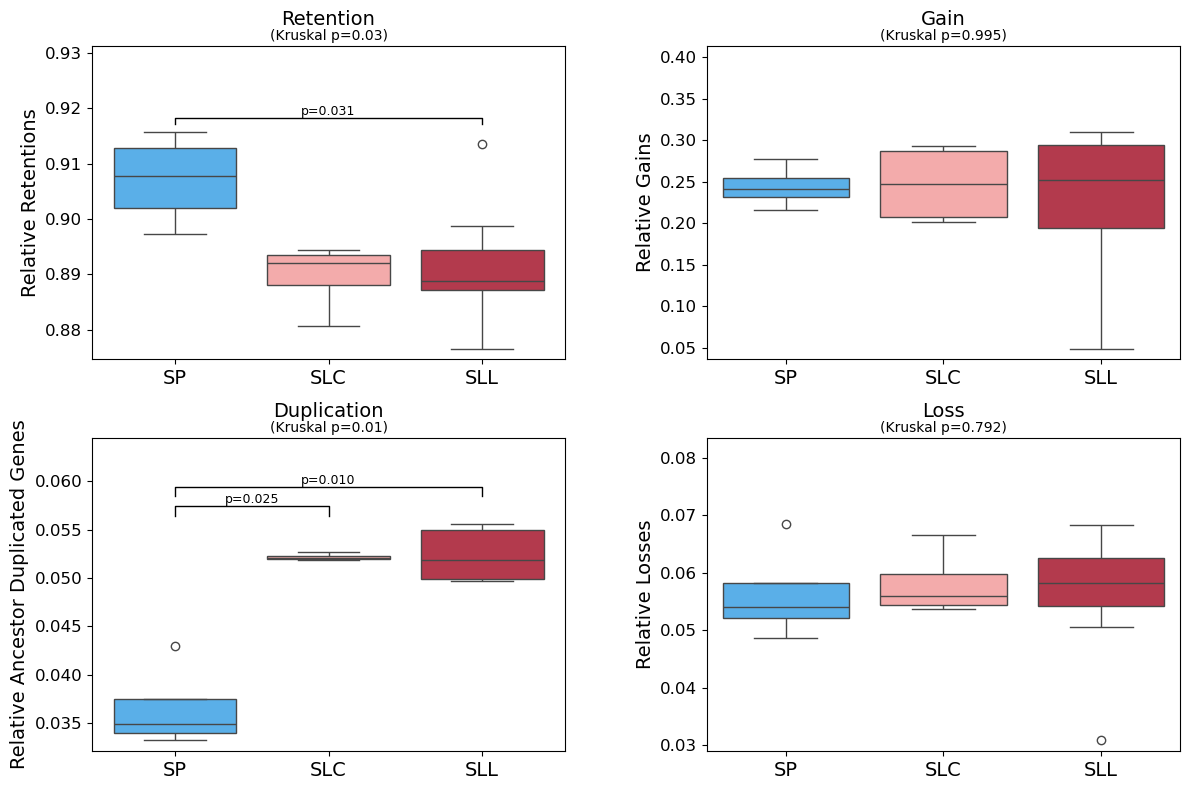

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal
import scikit_posthocs as sp
import numpy as np
from itertools import combinations

metrics = ['Retention proportion', 'Gain proportion', 'Duplication proportion', 'Loss proportion']


order=['SP', 'SLC', 'SLL']

# !! CHOOSE DF FOR TREE A OR C #########
df=noderesults_a

### Single tree version
subset=df[df['key_node_label']=='SLL_SLC_SP']
subset = subset[subset['child_classification'] != 'SLL_SLC_SP']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, m in enumerate(metrics):
    # -----------------------------
    # Kruskal test
    # -----------------------------
    grouped = [group[m].dropna().values
                for _, group in subset.groupby('child_classification')]
        
    stat, p = kruskal(*grouped)
    # -----------------------------
    # Plot
    # -----------------------------
    
    ax = axes[i]
    
    sns.boxplot(
        data=subset,
        x="child_classification",
        y=m,
        ax=ax,
        order=order,
        hue='child_classification',
        palette=palette
    )

    ax.set_ylabel(m.replace("_"," "), size=14)

    ax.tick_params(axis='y',labelsize=12)
    ax.tick_params(axis='x',labelsize=14)
    title_main= m.split(' ')[0]
    title_sub=f"(Kruskal p={round(p,3)})"
    
    ax.set_title(title_main, fontsize=14, pad=15)

    ax.text(
    0.5, 1.01, title_sub,
    transform=ax.transAxes,
    ha='center',
    va='bottom',
    fontsize=10
    )
    ax.set_xlabel('')
    
    
    y_max = subset[m].max()
    y_min = subset[m].min()
    y_range = y_max - y_min

    ax.set_ylim(y_min- 0.05*y_range, y_max + 0.40 * y_range)  # add 20% headroom
    
    #if title_main=='Retention':
    #    ax.set_ylim(y_min- 0.05*y_range, 1)
    
    # -----------------------------
    # Dunn post-hoc (ONLY if significant)
    # -----------------------------
    if p < 0.05:
        dunn = sp.posthoc_dunn(subset,val_col=m,
                group_col='child_classification',
                p_adjust='fdr_bh'
            )
        #print(dunn)
        # extract significant pairs
        sig_pairs = []
        for g1, g2 in combinations(order, 2):
            if g1 in dunn.index and g2 in dunn.columns:
                pval = dunn.loc[g1, g2]
                if pval < 0.05:
                    x1 = order.index(g1)
                    x2 = order.index(g2)
                    sig_pairs.append((x1, x2, pval))

        # -----------------------------
        # Draw brackets
        # -----------------------------
        if sig_pairs:
            y_max = subset[m].max()
            add_brackets(ax, sig_pairs, y_max +0.04*y_range)

axes[0].set_ylabel("Relative Retentions", size=14)
axes[1].set_ylabel("Relative Gains", size=14)
axes[2].set_ylabel("Relative Ancestor Duplicated Genes", size=14) 
## or Relative Duplications (if calculating the row "Duplication proportion" using "new_through_duplication" isntead of "duplicated_parent_count"

axes[3].set_ylabel("Relative Losses", size=14)

plt.tight_layout()
plt.subplots_adjust(hspace=0.25, wspace=0.3)
plt.savefig('/tree_a/path-wise-phylostratigraphy_parentduplicated.jpg',dpi=600)
plt.show()